In [1]:
#  Import core libraries for our PyTorch OCR pipeline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Download EMNIST (balanced split) and fix the known rotation/flip bug

from torchvision.transforms import functional as TF

# Custom transform function to undo EMNIST's built-in rotation + flip
def fix_emnist_rotation(img):
    img = TF.rotate(img, -90)          # rotate 90 degrees clockwise to undo the CCW rotation
    img = TF.hflip(img)                # horizontal flip to undo the mirroring
    return img

# Chain our fix together with the standard tensor conversion
transform = transforms.Compose([
    transforms.Lambda(fix_emnist_rotation),
    transforms.ToTensor()
])

# Download + load the EMNIST balanced split for both train and test sets
train_dataset = datasets.EMNIST(
    root='./data',
    split='balanced',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root='./data',
    split='balanced',
    train=False,
    download=True,
    transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

100%|██████████| 562M/562M [00:03<00:00, 160MB/s]


Train samples: 112800
Test samples: 18800
Number of classes: 47


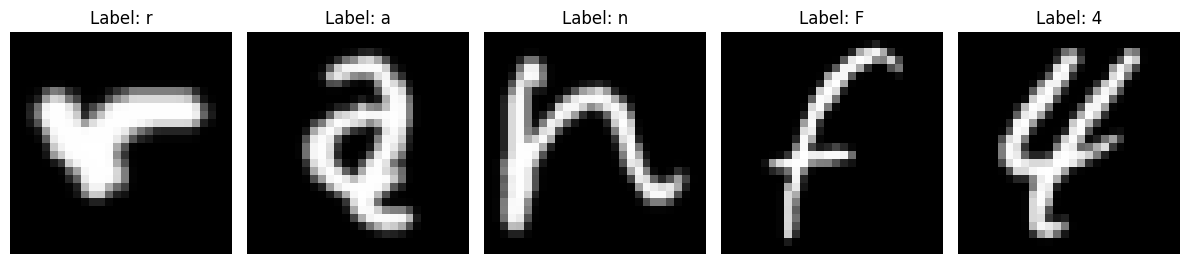

In [3]:
# Plot a few sample images from the training set to visually confirm the EMNIST rotation/flip fix worked correctly

emnist_classes = train_dataset.classes

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {emnist_classes[label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
#  Wrap our datasets in DataLoaders for batching + shuffling

batch_size = 64

train_loader = DataLoader(
  train_dataset,
  batch_size=batch_size,
  shuffle=True
)

test_loader = DataLoader(
  test_dataset,
  batch_size=batch_size,
  shuffle=False
)

images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])


In [5]:
# Defining our CNN architecture for EMNIST character classification

class OCRNet(nn.Module):
    def __init__(self, num_classes=47):
        super(OCRNet, self).__init__()

        # First conv block: 1 input channel (grayscale) -> 32 filters
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Second conv block: 32 filters -> 64 filters (going deeper = more complex features)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)

        # After 2 pooling operations: 28 -> 14 -> 7, so feature map is 7x7 with 64 channels
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = OCRNet(num_classes=47).to(device)
print(model)

OCRNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=47, bias=True)
)


In [6]:
# Defining loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [7]:
# Training loop — trains the model for a set number of epochs

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Epoch [1/5] - Loss: 0.8778 - Accuracy: 72.43%
Epoch [2/5] - Loss: 0.5658 - Accuracy: 80.92%
Epoch [3/5] - Loss: 0.5050 - Accuracy: 82.76%
Epoch [4/5] - Loss: 0.4632 - Accuracy: 84.13%
Epoch [5/5] - Loss: 0.4344 - Accuracy: 84.95%


In [8]:
# Evaluating the trained model on the unseen test set

model.eval()   # switch to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 87.04%


Saving handwritten.jpg to handwritten (1).jpg
Image shape: (49, 146)


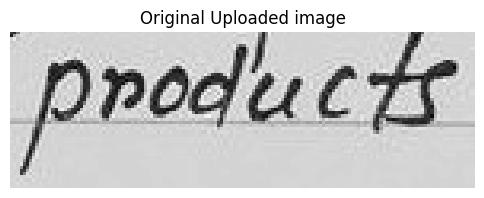

In [10]:
# Uploading a handwritten word image and load it with OpenCV

import cv2
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {img.shape}")

plt.figure(figsize=(6, 4))
plt.imshow(img, cmap='gray')
plt.title("Original Uploaded image")
plt.axis('off')
plt.show()

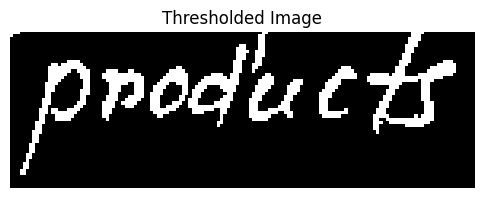

In [11]:
# Applying Otsu's thresholding to convert the image to pure black & white

# — this matters because OpenCV's contour finder looks for WHITE shapes on a BLACK background
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(6, 4))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

Number of contours found: 9


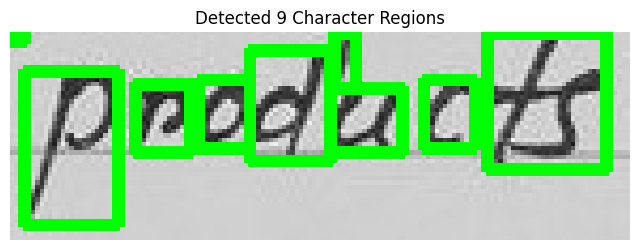

In [12]:
# Finding contours in the thresholded image and get sorted bounding boxes

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Number of contours found: {len(contours)}")

# Get bounding box (x, y, width, height) for each contour
bounding_boxes = [cv2.boundingRect(c) for c in contours]

bounding_boxes = sorted(bounding_boxes,key=lambda box: box[0])

img_with_boxes = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in bounding_boxes:
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 4))
plt.imshow(img_with_boxes)
plt.title(f"Detected {len(bounding_boxes)} Character Regions")
plt.axis('off')
plt.show()

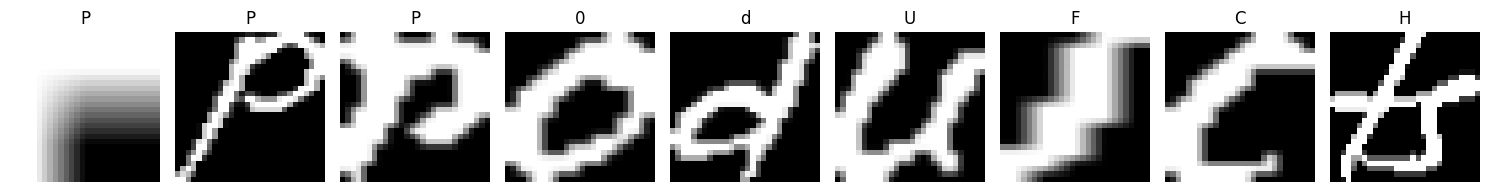

Predicted word: PPP0dUFCH


In [13]:
# Croping each detected character, preprocess it, and classify with our trained model

model.eval()

predicted_word = ""

fig, axes = plt.subplots(1, len(bounding_boxes), figsize=(15, 3))
for i, (x, y, w, h) in enumerate(bounding_boxes):
    char_crop = thresh[y:y+h, x:x+w]
    char_resized = cv2.resize(char_crop, (28, 28))
    char_normalized = char_resized / 255
    char_tensor = torch.tensor(char_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(char_tensor)
        _, pred = torch.max(output, 1)

    pred_char = emnist_classes[pred.item()]
    predicted_word += pred_char

    axes[i].imshow(char_resized, cmap='gray')
    axes[i].set_title(pred_char)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Predicted word: {predicted_word}")

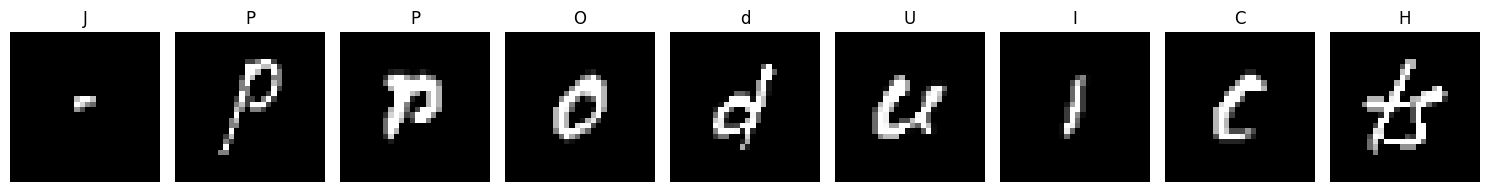

Predicted word: JPPOdUICH


In [14]:
# Re-run character extraction, this time with padding before resizing

def pad_to_square(char_crop, margin=10):
    h, w = char_crop.shape
    size = max(h, w) + margin * 2

    # Create a black square canvas of the target size
    square = np.zeros((size, size), dtype=np.uint8)

    # Compute top-left offset to paste the crop centered in the square
    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    square[y_offset:y_offset+h, x_offset:x_offset+w] = char_crop
    return square

model.eval()
predicted_word = ""

fig, axes = plt.subplots(1, len(bounding_boxes), figsize=(15, 3))

for i, (x, y, w, h) in enumerate(bounding_boxes):
    char_crop = thresh[y:y+h, x:x+w]

    # NEW STEP: pad to square before resizing
    char_padded = pad_to_square(char_crop, margin=10)

    char_resized = cv2.resize(char_padded, (28, 28))
    char_normalized = char_resized / 255
    char_tensor = torch.tensor(char_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(char_tensor)
        _, pred = torch.max(output, 1)

    pred_char = emnist_classes[pred.item()]
    predicted_word += pred_char

    axes[i].imshow(char_resized, cmap='gray')
    axes[i].set_title(pred_char)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print(f"Predicted word: {predicted_word}")